# Predictive Analytics for Personal Expenses & Financial Planning

**Project Description:**  
An end-to-end data analytics and machine-learning pipeline that ingests historical expense transactions, performs exploratory analysis, trains multiple forecasting models (Linear Regression, ARIMA, Prophet, LSTM), detects spending anomalies, runs what-if simulations, and exports actionable budget reports.

---
**Dataset Period:** January 2019 – December 2025 (7 years, 84 months)  
**Categories:** 12 expense categories (Rent, Groceries, Dining, Transport, Utilities, Healthcare, Insurance, Education, Travel, Entertainment, Subscriptions, Miscellaneous)  
**Data Files:**
-  — 7 366 individual transactions
-  — 1 008 monthly category aggregates


## 0. Environment Setup
Uncomment the lines below on first run to install dependencies.


In [1]:
# %pip install -q scikit-learn statsmodels prophet tensorflow matplotlib seaborn
# All libraries are standard in most data-science environments (Anaconda / Colab / Kaggle).


## 1. Imports & Global Configuration


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ML / Stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ── Global plot style ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
FIGSIZE_WIDE = (14, 4)
FIGSIZE_SQ   = (8, 6)
COLOR_ACTUAL = "#2563EB"      # blue
COLOR_FORE   = "#F59E0B"      # amber
COLOR_GOOD   = "#10B981"      # green  (income / savings)
COLOR_BAD    = "#EF4444"      # red    (anomaly / over-budget)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Project Configuration
Central place for all tunable parameters — change here, affects the whole notebook.


In [3]:
# ── File paths ────────────────────────────────────────────────────────────
TXN_CSV     = "datasets/expense_transactions_data.csv"
MONTHLY_CSV = "datasets/monthly_category_expenses_data.csv"

# ── Model hyperparameters ─────────────────────────────────────────────────
FORECAST_MONTHS = 12      # months to forecast into the future
TEST_MONTHS     = 6       # hold-out months for model evaluation
TOP_N_CATS      = 8       # top categories to focus on in forecasting
ARIMA_ORDER     = (2, 1, 2)
LSTM_WINDOW     = 6       # look-back window for LSTM sequences
LSTM_EPOCHS     = 60
LSTM_BATCH      = 16
RANDOM_STATE    = 42

# ── Budget benchmarks (INR/month) ─────────────────────────────────────────
BUDGET_LIMITS = {
    "Rent"          : 20_000,
    "Groceries"     : 12_000,
    "Dining"        :  5_000,
    "Transport"     :  4_000,
    "Utilities"     :  5_000,
    "Entertainment" :  3_000,
    "Healthcare"    :  4_000,
    "Insurance"     :  3_500,
    "Education"     :  3_000,
    "Travel"        :  5_000,
    "Subscriptions" :  1_500,
    "Miscellaneous" :  2_500,
}

print("Configuration loaded.")


Configuration loaded.


## 3. Data Loading & Validation


In [4]:
def load_transactions(path: str) -> pd.DataFrame:
    """Load and lightly validate the transactions CSV."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)
    df["amount_inr"] = pd.to_numeric(df["amount_inr"], errors="coerce")
    df.dropna(subset=["date", "amount_inr"], inplace=True)
    df.sort_values("date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def load_monthly(path: str) -> pd.DataFrame:
    """Load and validate the monthly category aggregates CSV."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df["period"] = pd.to_datetime(df["period"])
    df["monthly_expense_inr"] = pd.to_numeric(df["monthly_expense_inr"], errors="coerce")
    df.dropna(subset=["monthly_expense_inr"], inplace=True)
    return df


txn     = load_transactions(TXN_CSV)
monthly = load_monthly(MONTHLY_CSV)

print(f"Transactions : {txn.shape[0]:,} rows × {txn.shape[1]} columns")
print(f"Monthly agg  : {monthly.shape[0]:,} rows × {monthly.shape[1]} columns")
print(f"Date range   : {txn['date'].min().date()}  →  {txn['date'].max().date()}")
print(f"Categories   : {sorted(txn['category'].unique())}")
txn.head()


Transactions : 7,366 rows × 8 columns
Monthly agg  : 1,008 rows × 5 columns
Date range   : 2019-01-01  →  2025-12-31
Categories   : ['Dining', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Insurance', 'Miscellaneous', 'Rent', 'Subscriptions', 'Transport', 'Travel', 'Utilities']


,date,user_id,category,merchant,amount_inr,payment_method,is_recurring,recurring_code
0,2019-01-01,1001,Groceries,DMart,737.17,UPI,False,NaN
1,2019-01-01,1001,Education,Udemy,293.19,UPI,False,NaN
2,2019-01-01,1001,Groceries,DMart,348.53,UPI,False,NaN
3,2019-01-01,1001,Rent,ApartmentMgmt,11876.12,Credit Card,True,RENT
4,2019-01-02,1001,Transport,Metro,203.84,UPI,False,NaN


## 4. Feature Engineering — Wide Monthly Table
Pivot the monthly data so each category is a column; add .


In [5]:
def build_wide_table(monthly: pd.DataFrame) -> pd.DataFrame:
    """Pivot monthly long-format into wide format with DatetimeIndex."""
    wide = monthly.pivot_table(
        index="period", columns="category",
        values="monthly_expense_inr", aggfunc="sum"
    )
    wide.index = pd.DatetimeIndex(wide.index).to_period("M").to_timestamp("MS")
    wide.index.name = "month"
    wide.sort_index(inplace=True)
    wide = wide.asfreq("MS").fillna(0.0)
    wide["TOTAL_EXPENSE"] = wide.sum(axis=1)
    return wide


def build_wide_table(monthly: pd.DataFrame) -> pd.DataFrame:
    """Pivot monthly long-format into wide format with DatetimeIndex."""
    wide = monthly.pivot_table(
        index="period", columns="category",
        values="monthly_expense_inr", aggfunc="sum"
    )
    wide.index = pd.DatetimeIndex(wide.index)
    wide.index.name = "month"
    wide.sort_index(inplace=True)
    wide = wide.asfreq("MS").fillna(0.0)
    wide["TOTAL_EXPENSE"] = wide.sum(axis=1)
    return wide

wide = build_wide_table(monthly)

# Top-N categories by cumulative spend
cat_cols  = [c for c in wide.columns if c != "TOTAL_EXPENSE"]
cat_totals = wide[cat_cols].sum().sort_values(ascending=False)
top_cats   = cat_totals.head(TOP_N_CATS).index.tolist()

print(f"Wide table shape : {wide.shape}")
print(f"Top {TOP_N_CATS} categories: {top_cats}")
wide.tail()

# Top-N categories by cumulative spend
cat_cols  = [c for c in wide.columns if c != "TOTAL_EXPENSE"]
cat_totals = wide[cat_cols].sum().sort_values(ascending=False)
top_cats   = cat_totals.head(TOP_N_CATS).index.tolist()

print(f"Wide table shape : {wide.shape}")
print(f"Top {TOP_N_CATS} categories: {top_cats}")
wide.tail()


Wide table shape : (84, 13)
Top 8 categories: ['Rent', 'Groceries', 'Dining', 'Utilities', 'Travel', 'Transport', 'Insurance', 'Entertainment']
Wide table shape : (84, 13)
Top 8 categories: ['Rent', 'Groceries', 'Dining', 'Utilities', 'Travel', 'Transport', 'Insurance', 'Entertainment']


category,Dining,Education,Entertainment,Groceries,Healthcare,Insurance,Miscellaneous,Rent,Subscriptions,Transport,Travel,Utilities,TOTAL_EXPENSE
month,,,,,,,,,,,,,
2025-08-01,4889.53,2407.78,2781.57,14098.80,2570.72,3446.28,2064.37,26016.74,1122.33,3289.51,4432.94,4938.52,72059.09
2025-09-01,5224.78,2155.92,2625.01,12768.68,2730.73,3202.46,2128.91,25233.22,1047.65,3290.06,4316.77,5081.34,69805.53
2025-10-01,5292.13,2286.39,3283.96,12883.04,2718.89,3682.82,2086.17,26515.82,1208.36,3205.10,4652.18,5085.80,72900.66
2025-11-01,5614.96,2179.87,2938.39,13179.72,2677.48,3412.96,2730.54,25932.45,1142.86,3527.46,4620.83,4935.63,72893.15
2025-12-01,5465.70,1971.35,3650.77,13171.72,2521.94,3280.54,2057.56,24823.87,1101.60,3240.69,5477.09,5011.38,71774.21


## 5. Exploratory Data Analysis (EDA)


### 5.1 Total Monthly Expense Trend


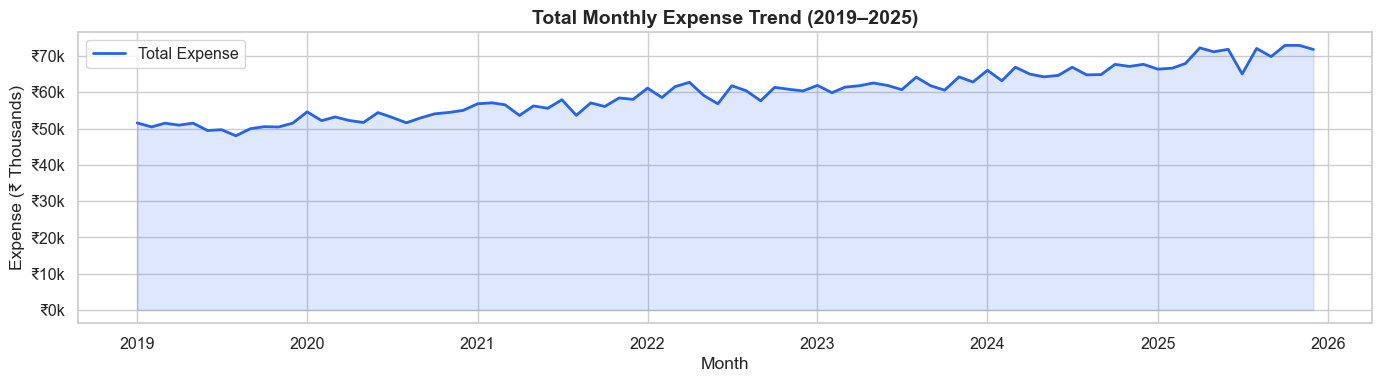

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(wide.index, wide["TOTAL_EXPENSE"] / 1000,
        color=COLOR_ACTUAL, linewidth=2, label="Total Expense")
ax.fill_between(wide.index, wide["TOTAL_EXPENSE"] / 1000,
                alpha=0.15, color=COLOR_ACTUAL)
ax.set_title("Total Monthly Expense Trend (2019–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Expense (₹ Thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 Category-Wise Total Spend


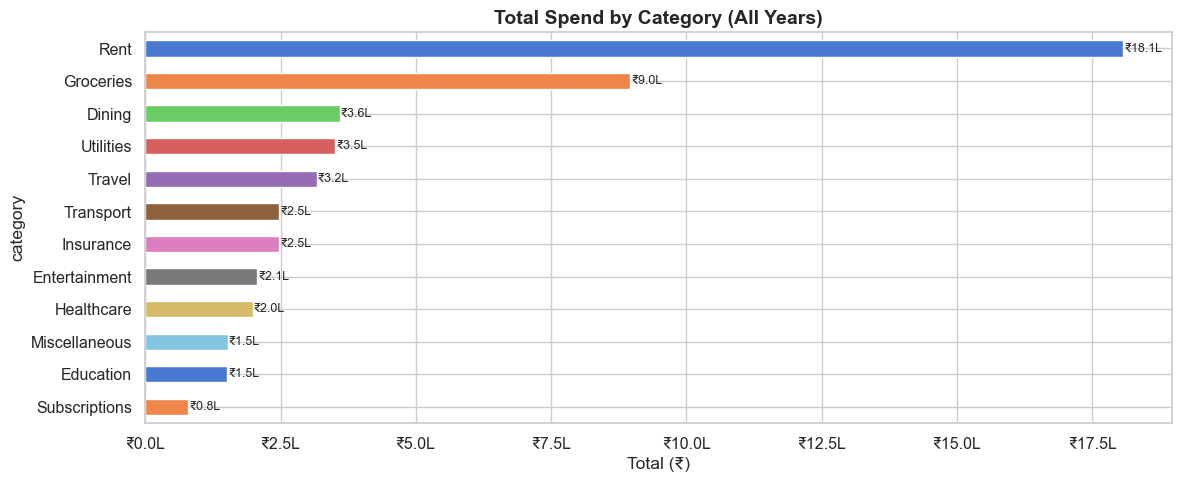

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("muted", len(cat_totals))
cat_totals.sort_values().plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.set_title("Total Spend by Category (All Years)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total (₹)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1_00_000:.1f}L"))
for bar in ax.patches:
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
            f"₹{bar.get_width()/1_00_000:.1f}L", va="center", fontsize=9)
plt.tight_layout()
plt.show()


### 5.3 Yearly Expense by Category (Stacked)


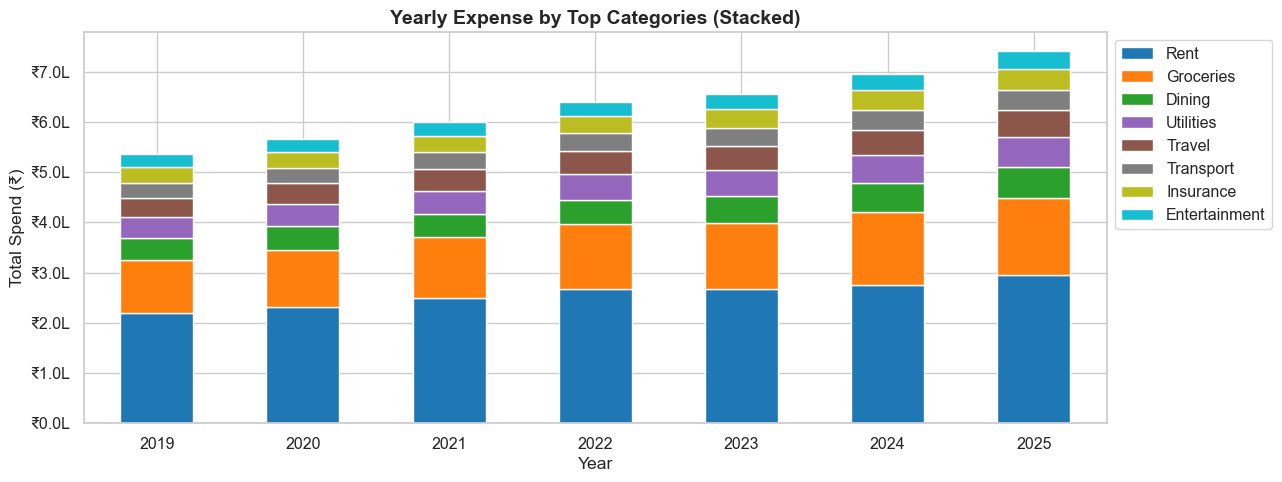

In [8]:
yearly = wide[top_cats].resample("YS").sum()
yearly.index = yearly.index.year
yearly.plot(kind="bar", stacked=True, figsize=(13, 5),
            colormap="tab10", edgecolor="white")
plt.title("Yearly Expense by Top Categories (Stacked)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Spend (₹)")
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1_00_000:.1f}L"))
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 5.4 Monthly Spend Seasonality (Heatmap)


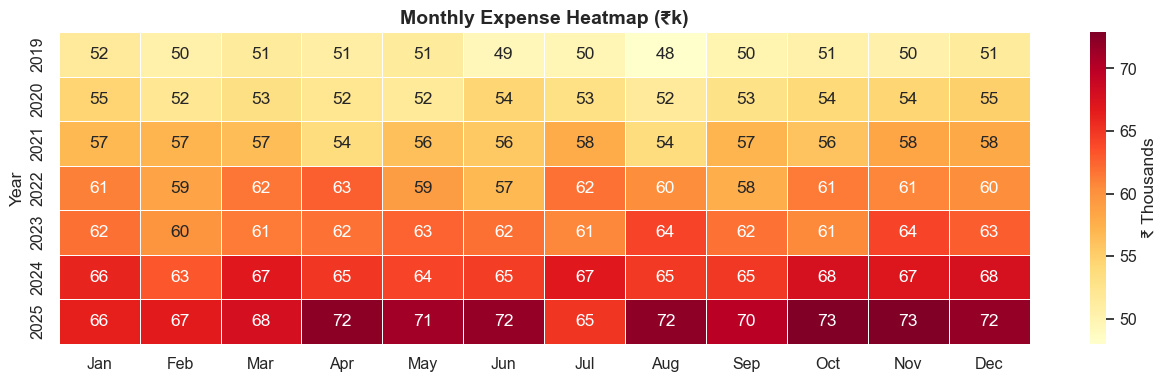

In [9]:
pivot_heat = wide["TOTAL_EXPENSE"].to_frame()
pivot_heat["year"]  = pivot_heat.index.year
pivot_heat["month"] = pivot_heat.index.month
heat = pivot_heat.pivot(index="year", columns="month", values="TOTAL_EXPENSE")
heat.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat / 1000, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "₹ Thousands"})
ax.set_title("Monthly Expense Heatmap (₹k)", fontsize=14, fontweight="bold")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()


### 5.5 Correlation Between Top Categories


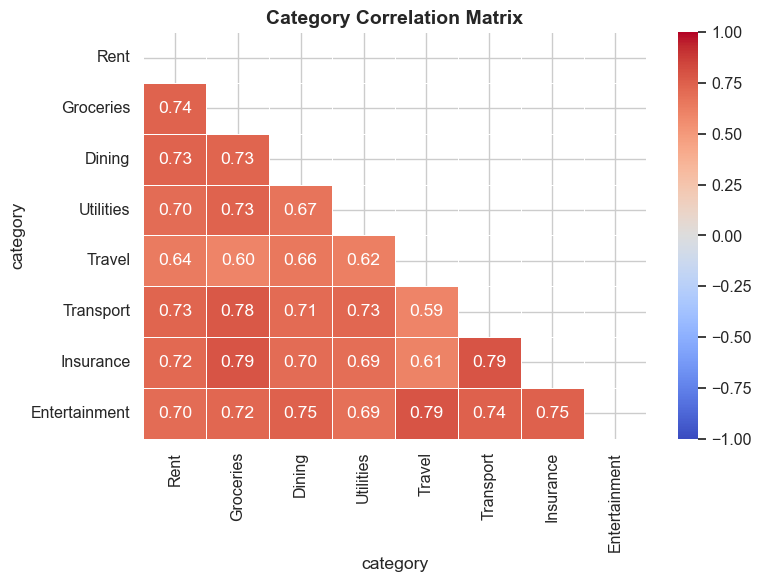

In [10]:
corr = wide[top_cats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax)
ax.set_title("Category Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 5.6 Transaction-Level Analysis


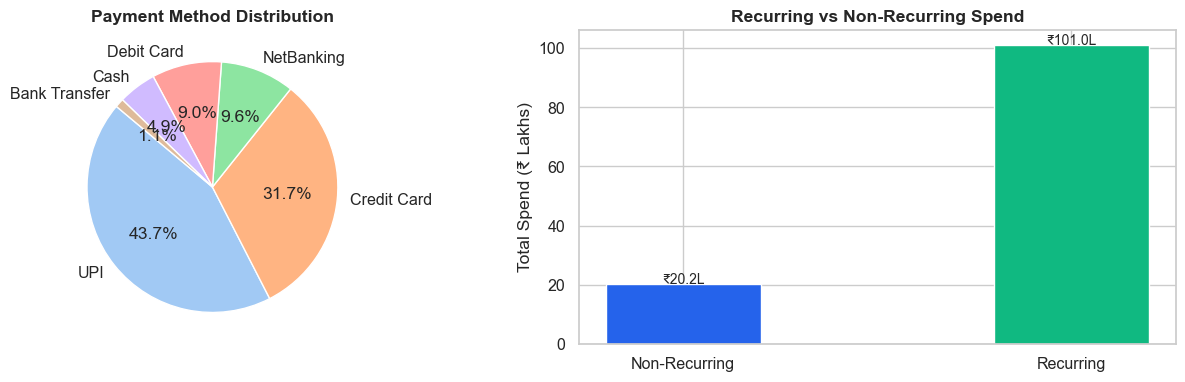

In [11]:
# Payment method distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pm = txn["payment_method"].value_counts()
axes[0].pie(pm.values, labels=pm.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"), startangle=140)
axes[0].set_title("Payment Method Distribution", fontweight="bold")

# Recurring vs non-recurring spend
rec_spend = txn.groupby("is_recurring")["amount_inr"].sum()
rec_spend.index = ["Non-Recurring", "Recurring"]
axes[1].bar(rec_spend.index, rec_spend.values / 1_00_000,
            color=[COLOR_ACTUAL, COLOR_GOOD], edgecolor="white", width=0.4)
axes[1].set_title("Recurring vs Non-Recurring Spend", fontweight="bold")
axes[1].set_ylabel("Total Spend (₹ Lakhs)")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f"₹{bar.get_height():.1f}L", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 6. Forecasting Models
### 6.1 Helper Functions


In [12]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def train_test_split_series(series: pd.Series, test_months: int):
    """Split a time series into train/test preserving order."""
    series = series.dropna()
    test_months = min(test_months, max(1, len(series) // 4))
    return series.iloc[:-test_months], series.iloc[-test_months:]


def future_date_index(series: pd.Series, months_ahead: int) -> pd.DatetimeIndex:
    return pd.date_range(
        start=series.index.max() + pd.offsets.MonthBegin(1),
        periods=months_ahead, freq="MS"
    )


print("Metric helpers ready.")


Metric helpers ready.


### 6.2 Linear Regression Forecaster


In [13]:
def regression_forecast(series: pd.Series,
                         months_ahead: int = FORECAST_MONTHS,
                         test_months: int  = TEST_MONTHS):
    """
    Lag-feature linear regression forecaster.
    Returns: (pred_test, y_test, future_series)
    """
    s = series.copy().dropna()

    # Build lag features
    df = pd.DataFrame({"y": s})
    for lag in (1, 2, 3):
        df[f"lag{lag}"] = df["y"].shift(lag)
    df["roll3"]     = df["y"].rolling(3).mean()
    df["month_num"] = df.index.month
    df.dropna(inplace=True)

    features = ["lag1", "lag2", "lag3", "roll3", "month_num"]
    test_months = min(test_months, max(1, len(df) // 4))
    train_df, test_df = df.iloc[:-test_months], df.iloc[-test_months:]

    model = LinearRegression()
    model.fit(train_df[features], train_df["y"])

    pred_test = model.predict(test_df[features])
    y_test    = test_df["y"].values

    # Recursive multi-step future forecast
    history = list(s.values[-3:])
    future_vals = []
    last_month  = s.index[-1].month
    for step in range(months_ahead):
        roll3 = float(np.mean(history[-3:]))
        m_num = ((last_month + step) % 12) + 1
        x = np.array([[history[-1], history[-2], history[-3], roll3, m_num]])
        val = float(model.predict(x)[0])
        future_vals.append(max(0.0, val))
        history.append(val)

    future = pd.Series(future_vals, index=future_date_index(s, months_ahead),
                        name="Regression")
    return pred_test, y_test, future


print("Regression forecaster ready.")


Regression forecaster ready.


### 6.3 ARIMA Forecaster


In [14]:
def arima_forecast(series: pd.Series,
                   months_ahead: int = FORECAST_MONTHS,
                   test_months:  int = TEST_MONTHS,
                   order: tuple      = ARIMA_ORDER):
    """
    ARIMA time-series forecaster.
    Returns: (pred_test, y_test, future_series)
    """
    train, test = train_test_split_series(series, test_months)

    model    = ARIMA(train, order=order).fit()
    fc_full  = model.forecast(steps=len(test) + months_ahead)

    pred_test = fc_full.iloc[:len(test)].values
    future_vals = fc_full.iloc[len(test):].values

    future = pd.Series(future_vals,
                        index=future_date_index(series, months_ahead),
                        name="ARIMA")
    return pred_test, test.values, future


print("ARIMA forecaster ready.")


ARIMA forecaster ready.


### 6.4 Prophet Forecaster


In [15]:
def prophet_forecast(series: pd.Series,
                      months_ahead: int = FORECAST_MONTHS,
                      test_months:  int = TEST_MONTHS):
    """
    Facebook Prophet forecaster (handles seasonality / holidays).
    Returns: (pred_test, y_test, future_series)
    """
    s = series.reset_index()
    s.columns = ["ds", "y"]
    s["ds"] = pd.to_datetime(s["ds"])
    s.sort_values("ds", inplace=True)

    test_months = min(test_months, max(1, len(s) // 4))
    train, test = s.iloc[:-test_months].copy(), s.iloc[-test_months:].copy()

    m = Prophet(yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False)
    m.fit(train)

    future_df = m.make_future_dataframe(periods=test_months + months_ahead, freq="MS")
    fc        = m.predict(future_df)

    pred_test   = fc.iloc[-test_months - months_ahead:-months_ahead]["yhat"].values
    future_vals = fc.iloc[-months_ahead:]["yhat"].values
    future_vals = np.maximum(future_vals, 0.0)

    future = pd.Series(future_vals,
                        index=future_date_index(series, months_ahead),
                        name="Prophet")
    return pred_test, test["y"].values, future


print("Prophet forecaster ready.")


Prophet forecaster ready.


### 6.5 LSTM Forecaster


In [16]:
def create_sequences(arr: np.ndarray, window: int):
    """Create sliding-window (X, y) pairs for LSTM."""
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i])
        y.append(arr[i])
    return np.array(X), np.array(y)


def lstm_forecast(series: pd.Series,
                   months_ahead: int = FORECAST_MONTHS,
                   test_months:  int = TEST_MONTHS,
                   window:       int = LSTM_WINDOW,
                   n_epochs:     int = LSTM_EPOCHS,
                   batch:        int = LSTM_BATCH):
    """
    Single-layer LSTM forecaster.
    Returns: (pred_test, y_test, future_series)
    """
    arr = series.dropna().astype(float).values
    scaler = MinMaxScaler()
    arr_scaled = scaler.fit_transform(arr.reshape(-1, 1)).flatten()

    X, y = create_sequences(arr_scaled, window)
    test_months = min(test_months, max(1, len(X) // 4))
    split = len(X) - test_months

    X_train, X_test = X[:split].reshape(-1, window, 1), X[split:].reshape(-1, window, 1)
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        LSTM(32, input_shape=(window, 1)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch, verbose=0)

    pred_test_scaled = model.predict(X_test, verbose=0).flatten()
    pred_test = scaler.inverse_transform(pred_test_scaled.reshape(-1, 1)).flatten()
    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Recursive future forecast
    buf = list(arr_scaled[-window:])
    future_vals = []
    for _ in range(months_ahead):
        x_in = np.array(buf[-window:]).reshape(1, window, 1)
        pred = float(model.predict(x_in, verbose=0).flatten()[0])
        future_vals.append(pred)
        buf.append(pred)
    future_inv = scaler.inverse_transform(
        np.array(future_vals).reshape(-1, 1)).flatten()
    future_inv = np.maximum(future_inv, 0.0)

    future = pd.Series(future_inv,
                        index=future_date_index(series, months_ahead),
                        name="LSTM")
    return pred_test, y_test_orig, future


print("LSTM forecaster ready.")


LSTM forecaster ready.


### 6.6 Model Evaluation & Comparison Per Category


In [17]:
FORECASTERS = {
    "Regression": regression_forecast,
    "ARIMA"     : arima_forecast,
    "Prophet"   : prophet_forecast,
    "LSTM"      : lstm_forecast,
}


def evaluate_category(cat_name: str, series: pd.Series) -> dict:
    """
    Fit all four models for one category.
    Returns a dict with keys: 'perf' (DataFrame), '<Model>_future' (Series).
    """
    results  = {}
    perf_rows = []

    for model_name, fn in FORECASTERS.items():
        try:
            pred_test, y_test, future = fn(series)
            mae_v  = mean_absolute_error(y_test, pred_test)
            rmse_v = rmse(y_test, pred_test)
            mape_v = mape(y_test, pred_test)
            perf_rows.append({
                "Model": model_name, "MAE": round(mae_v, 2),
                "RMSE": round(rmse_v, 2), "MAPE (%)": round(mape_v, 2)
            })
            results[f"{model_name}_future"] = future
        except Exception as exc:
            print(f"  [{cat_name}] {model_name} failed: {exc}")
            perf_rows.append({"Model": model_name, "MAE": np.nan,
                               "RMSE": np.nan, "MAPE (%)": np.nan})
            results[f"{model_name}_future"] = None

    perf_df = pd.DataFrame(perf_rows).sort_values("RMSE").reset_index(drop=True)
    results["perf"] = perf_df
    return results


print("Evaluation harness ready.")


Evaluation harness ready.


### 6.7 Run Forecasting Across All Top Categories
> This cell trains 4 models × 8 categories = 32 model fits. LSTM may take ~2–4 min.


In [18]:
category_results = {}

for cat in top_cats:
    print(f"══ Forecasting: {cat} ══")
    s = wide[cat].copy().asfreq("MS").fillna(0.0)
    info = evaluate_category(cat, s)
    category_results[cat] = info
    print(info["perf"].to_string(index=False))

print("✅ All categories forecasted.")


══ Forecasting: Rent ══


22:55:17 - cmdstanpy - INFO - Chain [1] start processing
22:55:19 - cmdstanpy - INFO - Chain [1] done processing
d:\Personal-Expense-and-financial-planning\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
22:55:24 - cmdstanpy - INFO - Chain [1] start processing


     Model     MAE    RMSE  MAPE (%)
Regression    0.00    0.00      0.00
      LSTM 1235.55 1672.15      5.34
     ARIMA 1213.56 1838.23      5.34
   Prophet 1830.90 2176.62      7.68
══ Forecasting: Groceries ══


22:55:24 - cmdstanpy - INFO - Chain [1] done processing
22:55:29 - cmdstanpy - INFO - Chain [1] start processing


     Model    MAE    RMSE  MAPE (%)
Regression   0.00    0.00      0.00
     ARIMA 410.94  610.81      3.01
      LSTM 538.51  797.63      3.94
   Prophet 832.63 1033.78      6.15
══ Forecasting: Dining ══


...

     Model    MAE   RMSE  MAPE (%)
Regression   0.00   0.00      0.00
   Prophet 199.17 220.83      6.16
      LSTM 231.92 248.71      7.15
     ARIMA 241.89 270.32      7.51
══ Forecasting: Insurance ══


d:\Personal-Expense-and-financial-planning\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
22:55:47 - cmdstanpy - INFO - Chain [1] start processing
22:55:47 - cmdstanpy - INFO - Chain [1] done processing
22:55:52 - cmdstanpy - INFO - Chain [1] start processing


     Model    MAE   RMSE  MAPE (%)
Regression   0.00   0.00      0.00
   Prophet 150.62 168.61      4.49
     ARIMA 187.70 205.05      5.62
      LSTM 237.62 265.71      7.15
══ Forecasting: Entertainment ══


22:55:52 - cmdstanpy - INFO - Chain [1] done processing


     Model    MAE   RMSE  MAPE (%)
Regression   0.00   0.00      0.00
   Prophet 172.34 222.84      5.55
     ARIMA 282.82 360.88      8.93
      LSTM 317.76 375.20     10.30
✅ All categories forecasted.


### 6.8 Forecast Plots — Best Model per Category


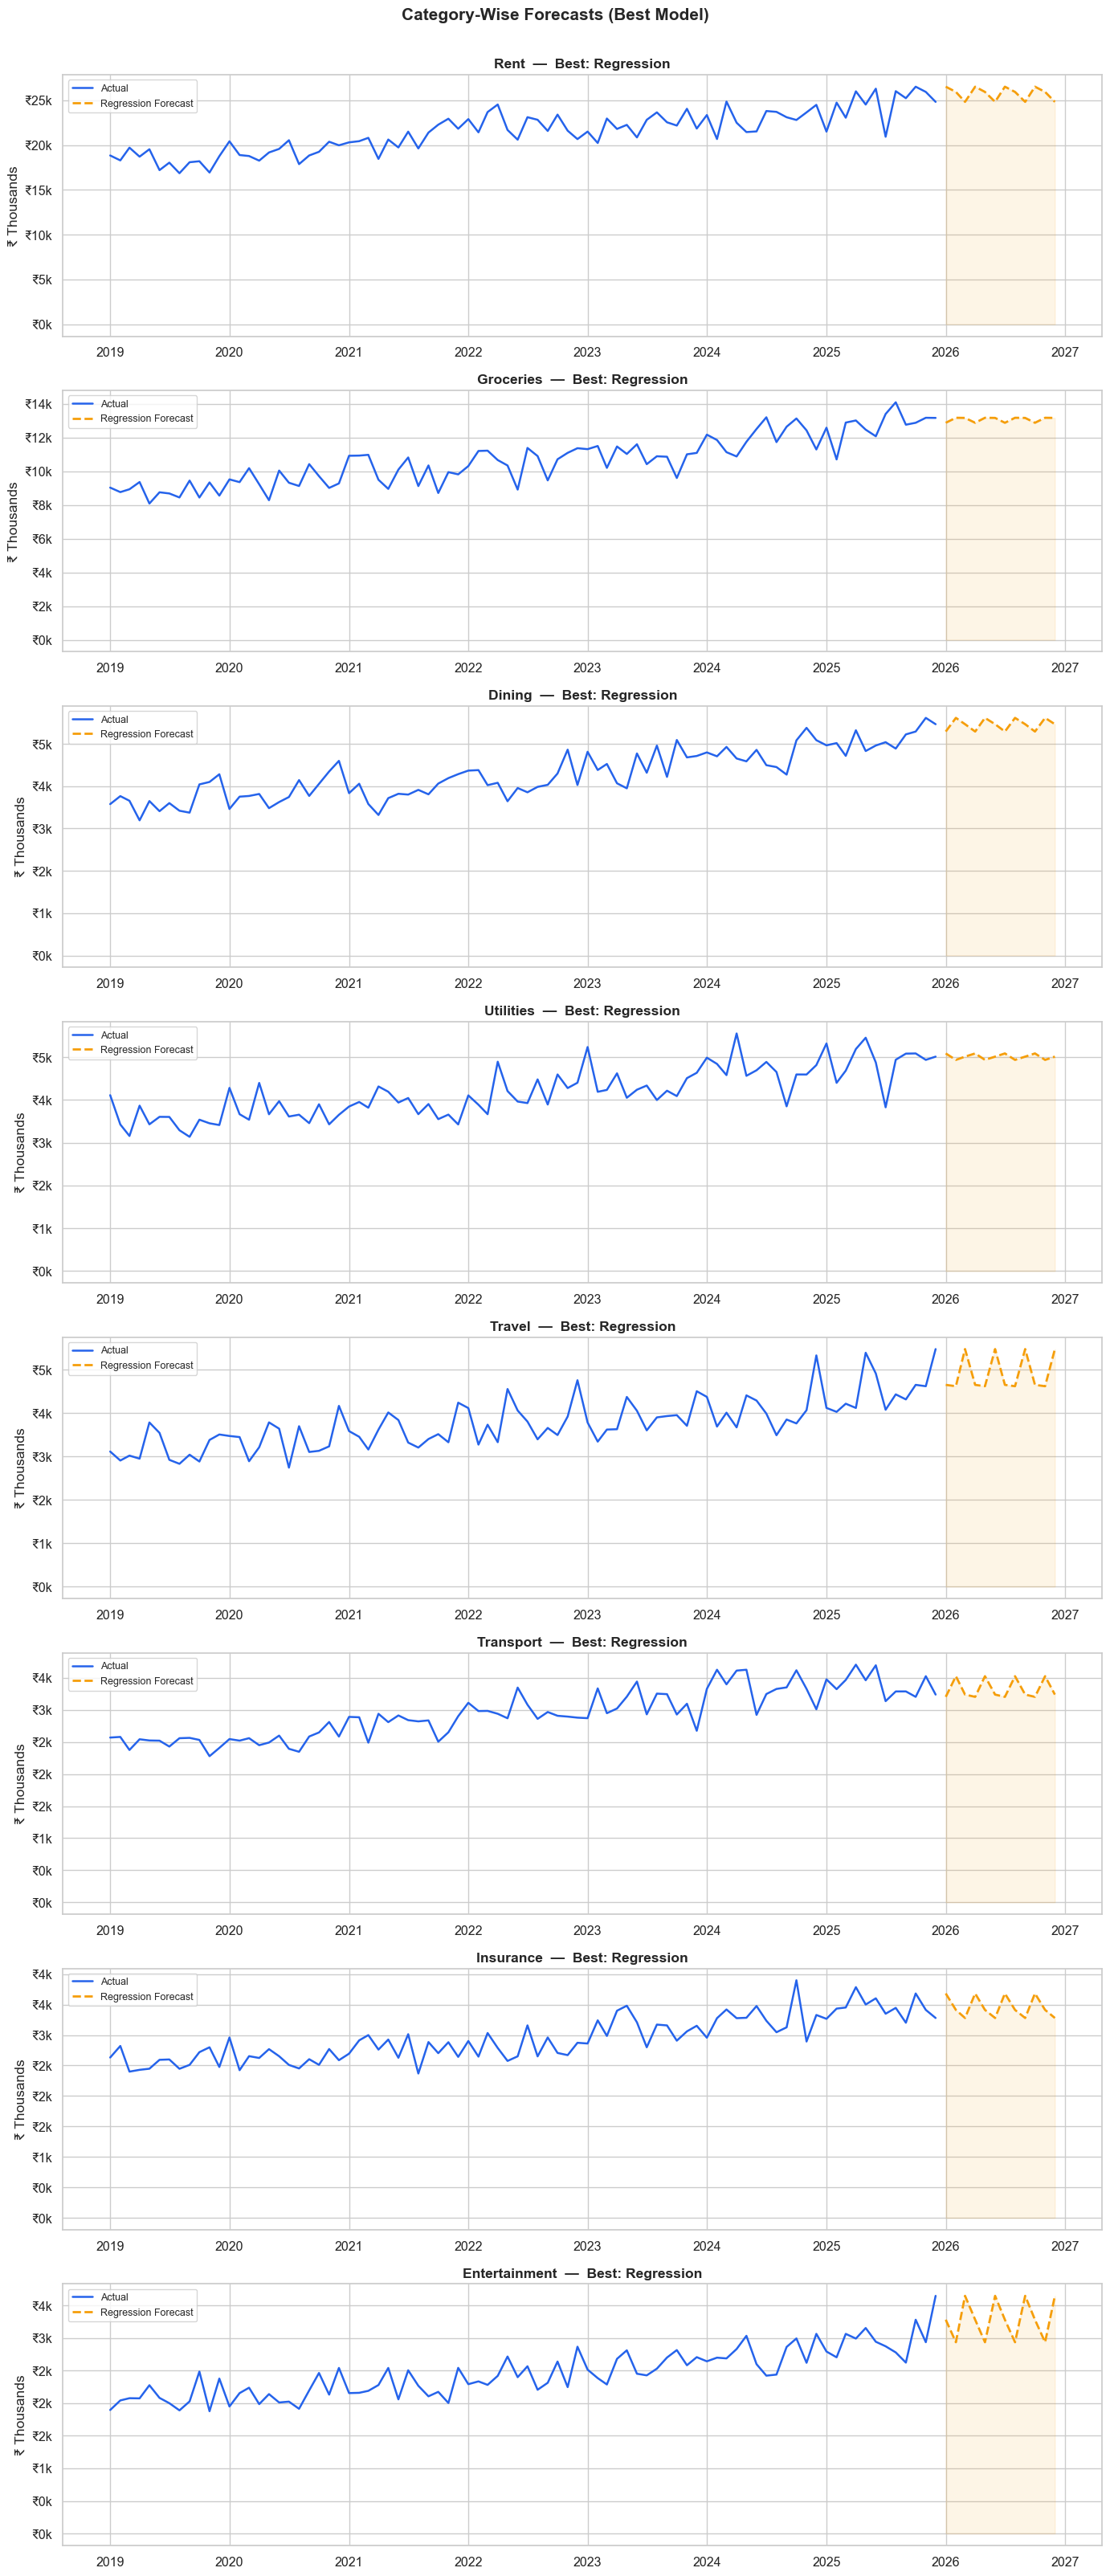

In [19]:
fig, axes = plt.subplots(len(top_cats), 1,
                          figsize=(14, 4 * len(top_cats)), sharex=False)

for ax, cat in zip(axes, top_cats):
    info       = category_results[cat]
    best_model = info["perf"].iloc[0]["Model"]
    future     = info.get(f"{best_model}_future")
    s          = wide[cat].copy()

    ax.plot(s.index, s.values / 1000, color=COLOR_ACTUAL,
            linewidth=1.8, label="Actual")
    if isinstance(future, pd.Series):
        ax.plot(future.index, future.values / 1000,
                color=COLOR_FORE, linewidth=2,
                linestyle="--", label=f"{best_model} Forecast")
        ax.fill_between(future.index, 0,
                         future.values / 1000,
                         alpha=0.10, color=COLOR_FORE)
    ax.set_title(f"{cat}  —  Best: {best_model}", fontweight="bold")
    ax.set_ylabel("₹ Thousands")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
    ax.legend(fontsize=9)

plt.suptitle("Category-Wise Forecasts (Best Model)",
             fontsize=15, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()


### 6.9 Consolidated 12-Month Forecast Table


In [20]:
future_idx = future_date_index(wide[top_cats[0]], FORECAST_MONTHS)
future_table = pd.DataFrame(index=future_idx)

for cat in top_cats:
    info       = category_results[cat]
    best_model = info["perf"].iloc[0]["Model"]
    future     = info.get(f"{best_model}_future")
    future_table[cat] = future.values if isinstance(future, pd.Series) else np.nan

future_table["TOTAL_FORECAST"] = future_table.sum(axis=1)
future_table.index.name = "Month"

print("Forecasted Monthly Expenses (INR) — Next 12 Months")
future_table.applymap(lambda x: f"₹{x:,.0f}").to_string()
future_table


Forecasted Monthly Expenses (INR) — Next 12 Months


,Rent,Groceries,Dining,Utilities,Travel,Transport,Insurance,Entertainment,TOTAL_FORECAST
Month,,,,,,,,,
2026-01-01,26515.82,12883.04,5292.13,5085.80,4652.18,3205.10,3682.82,3283.96,64600.85
2026-02-01,25932.45,13179.72,5614.96,4935.63,4620.83,3527.46,3412.96,2938.39,64162.40
2026-03-01,24823.87,13171.72,5465.70,5011.38,5477.09,3240.69,3280.54,3650.77,64121.76
2026-04-01,26515.82,12883.04,5292.13,5085.80,4652.18,3205.10,3682.82,3283.96,64600.85
2026-05-01,25932.45,13179.72,5614.96,4935.63,4620.83,3527.46,3412.96,2938.39,64162.40
2026-06-01,24823.87,13171.72,5465.70,5011.38,5477.09,3240.69,3280.54,3650.77,64121.76
2026-07-01,26515.82,12883.04,5292.13,5085.80,4652.18,3205.10,3682.82,3283.96,64600.85
2026-08-01,25932.45,13179.72,5614.96,4935.63,4620.83,3527.46,3412.96,2938.39,64162.40
2026-09-01,24823.87,13171.72,5465.70,5011.38,5477.09,3240.69,3280.54,3650.77,64121.76


### 6.10 Upcoming High-Spend Category Ranking


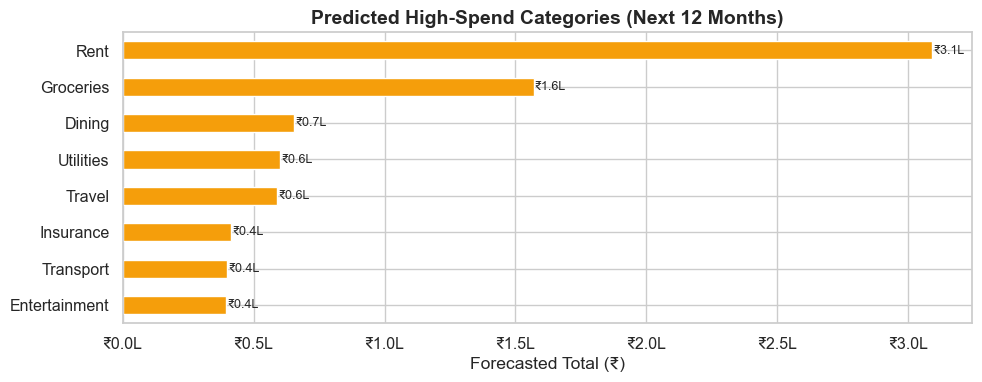

Ranking (highest to lowest predicted spend):
  1. Rent               ₹   309,089
  2. Groceries          ₹   156,938
  3. Dining             ₹    65,491
  4. Utilities          ₹    60,131
  5. Travel             ₹    59,000
  6. Insurance          ₹    41,505
  7. Transport          ₹    39,893
  8. Entertainment      ₹    39,492


In [21]:
pred_totals = future_table[top_cats].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
pred_totals.sort_values().plot(kind="barh", ax=ax, color=COLOR_FORE, edgecolor="white")
ax.set_title("Predicted High-Spend Categories (Next 12 Months)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Forecasted Total (₹)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x/1_00_000:.1f}L"))
for bar in ax.patches:
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
            f"₹{bar.get_width()/1_00_000:.1f}L", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Ranking (highest to lowest predicted spend):")
for rank, (cat, val) in enumerate(pred_totals.items(), 1):
    print(f"  {rank}. {cat:<18} ₹{val:>10,.0f}")


## 7. Budget Planning — Forecast vs Budget Limits


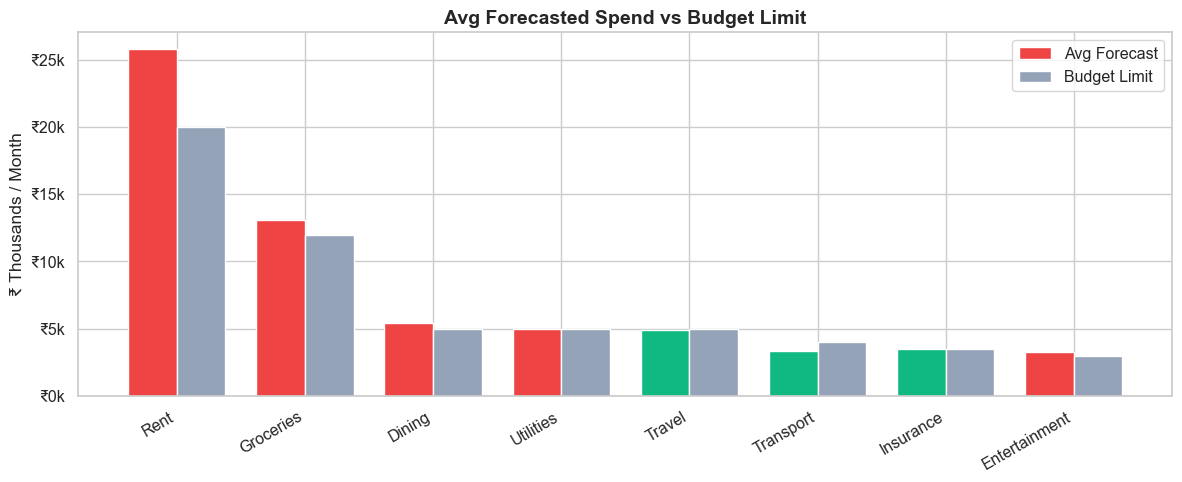

Over-budget categories:
  ⚠  Rent               Forecast ₹  25,757  Budget ₹  20,000  Over by ₹ 5,757
  ⚠  Groceries          Forecast ₹  13,078  Budget ₹  12,000  Over by ₹ 1,078
  ⚠  Dining             Forecast ₹   5,458  Budget ₹   5,000  Over by ₹   458
  ⚠  Utilities          Forecast ₹   5,011  Budget ₹   5,000  Over by ₹    11
  ⚠  Entertainment      Forecast ₹   3,291  Budget ₹   3,000  Over by ₹   291


In [22]:
avg_forecast = future_table[top_cats].mean()  # average monthly forecast

budget_df = pd.DataFrame({
    "Category"     : list(avg_forecast.index),
    "Avg_Forecast"  : avg_forecast.values,
    "Budget_Limit"  : [BUDGET_LIMITS.get(c, np.nan) for c in avg_forecast.index],
})
budget_df["Over_Budget"] = budget_df["Avg_Forecast"] > budget_df["Budget_Limit"]
budget_df["Delta"]       = budget_df["Avg_Forecast"] - budget_df["Budget_Limit"]

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(budget_df))
width   = 0.38
colors  = [COLOR_BAD if ob else COLOR_GOOD for ob in budget_df["Over_Budget"]]

ax.bar(x - width/2, budget_df["Avg_Forecast"] / 1000, width,
       color=colors, label="Avg Forecast", edgecolor="white")
ax.bar(x + width/2, budget_df["Budget_Limit"] / 1000, width,
       color="#94A3B8", label="Budget Limit", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(budget_df["Category"], rotation=30, ha="right")
ax.set_ylabel("₹ Thousands / Month")
ax.set_title("Avg Forecasted Spend vs Budget Limit",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()

print("Over-budget categories:")
ob = budget_df[budget_df["Over_Budget"]][["Category", "Avg_Forecast", "Budget_Limit", "Delta"]]
if ob.empty:
    print("  None — all categories within budget!")
else:
    for _, row in ob.iterrows():
        print(f"  ⚠  {row['Category']:<18} Forecast ₹{row['Avg_Forecast']:>8,.0f}  "
              f"Budget ₹{row['Budget_Limit']:>8,.0f}  Over by ₹{row['Delta']:>6,.0f}")


## 8. What-If Scenario Simulation
Simulate expense adjustments and see their impact on the 12-month forecast.


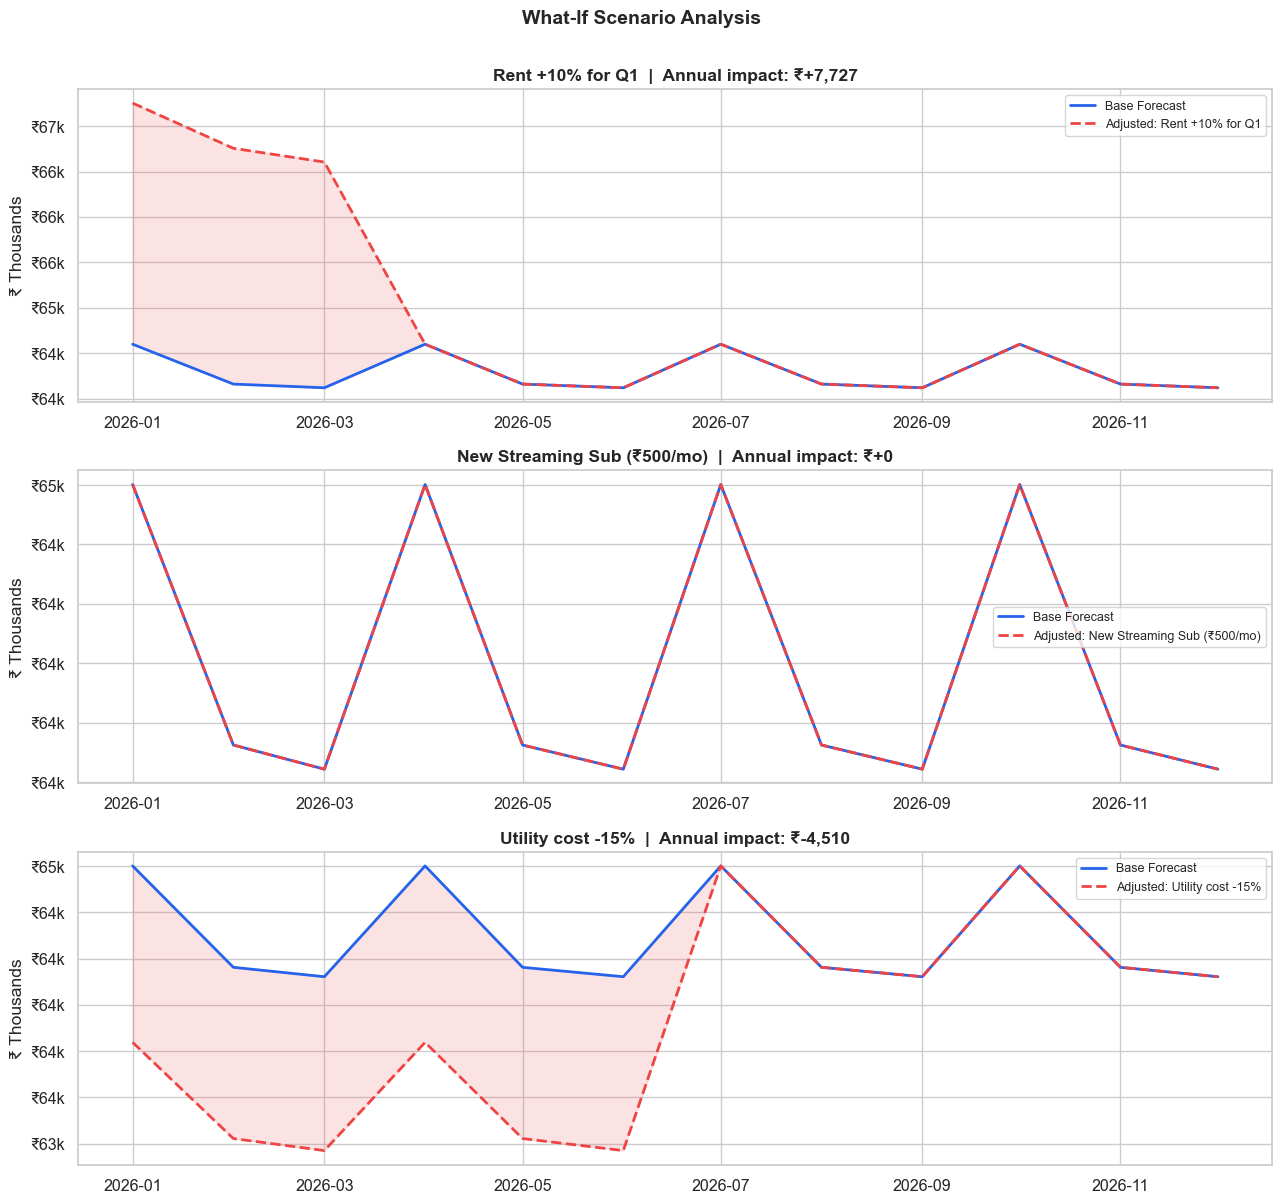

In [23]:
SCENARIOS = [
    {"name": "Rent +10% for Q1",           "category": "Rent",          "type": "pct",   "value": 0.10, "months": 3},
    {"name": "New Streaming Sub (₹500/mo)",  "category": "Subscriptions", "type": "fixed", "value": 500.0, "months": 12},
    {"name": "Utility cost -15%",            "category": "Utilities",     "type": "pct",   "value": -0.15, "months": 6},
]


def apply_scenario(base_table: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    """Return a copy of future_table with the scenario adjustment applied."""
    adj = base_table.copy()
    cat = scenario["category"]
    if cat not in adj.columns:
        return adj
    n = min(scenario["months"], len(adj))
    if scenario["type"] == "pct":
        adj.iloc[:n, adj.columns.get_loc(cat)] *= (1 + scenario["value"])
    elif scenario["type"] == "fixed":
        adj.iloc[:n, adj.columns.get_loc(cat)] += scenario["value"]
    adj["TOTAL_FORECAST"] = adj[top_cats].sum(axis=1)
    return adj


# Run & visualise scenarios
fig, axes = plt.subplots(len(SCENARIOS), 1,
                          figsize=(13, 4 * len(SCENARIOS)))

for ax, sc in zip(axes, SCENARIOS):
    adj = apply_scenario(future_table, sc)
    ax.plot(future_table.index, future_table["TOTAL_FORECAST"] / 1000,
            color=COLOR_ACTUAL, linewidth=2, label="Base Forecast")
    ax.plot(adj.index, adj["TOTAL_FORECAST"] / 1000,
            color=COLOR_BAD, linewidth=2, linestyle="--",
            label=f"Adjusted: {sc['name']}")
    ax.fill_between(adj.index,
                     future_table["TOTAL_FORECAST"] / 1000,
                     adj["TOTAL_FORECAST"] / 1000,
                     alpha=0.15, color=COLOR_BAD)
    diff = adj["TOTAL_FORECAST"].sum() - future_table["TOTAL_FORECAST"].sum()
    ax.set_title(f"{sc['name']}  |  Annual impact: ₹{diff:+,.0f}",
                 fontweight="bold")
    ax.set_ylabel("₹ Thousands")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
    ax.legend(fontsize=9)

plt.suptitle("What-If Scenario Analysis", fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()


## 9. Anomaly Detection
### 9.1 Monthly-Level Anomalies (Isolation Forest)


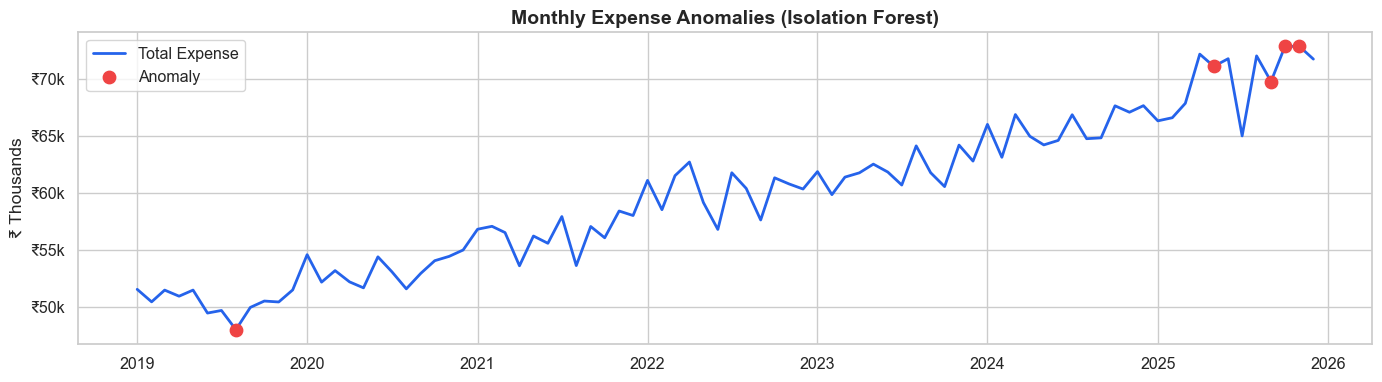

Anomalous months detected: 5
           Total_Expense
month                   
2019-08-01       ₹47,991
2025-05-01       ₹71,137
2025-09-01       ₹69,806
2025-10-01       ₹72,901
2025-11-01       ₹72,893


In [24]:
monthly_total = wide["TOTAL_EXPENSE"].copy().asfreq("MS").fillna(0.0)

iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
labels = iso.fit_predict(monthly_total.values.reshape(-1, 1))

anom_df = pd.DataFrame({
    "Total_Expense": monthly_total.values,
    "Anomaly"      : labels
}, index=monthly_total.index)

anomaly_months = anom_df[anom_df["Anomaly"] == -1]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(monthly_total.index, monthly_total / 1000,
        color=COLOR_ACTUAL, linewidth=2, label="Total Expense")
ax.scatter(anomaly_months.index, anomaly_months["Total_Expense"] / 1000,
            color=COLOR_BAD, s=80, zorder=5, label="Anomaly")
ax.set_title("Monthly Expense Anomalies (Isolation Forest)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("₹ Thousands")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Anomalous months detected: {len(anomaly_months)}")
print(anomaly_months[["Total_Expense"]].applymap(lambda x: f"₹{x:,.0f}"))


### 9.2 Transaction-Level Anomalies (Z-Score)


In [25]:
amt = txn["amount_inr"].astype(float)
z_scores = (amt - amt.mean()) / (amt.std() + 1e-9)
txn_anom = txn.copy()
txn_anom["z_score"] = z_scores
txn_anom["is_anomaly"] = z_scores.abs() > 3

print(f"Transaction anomalies (|z| > 3): {txn_anom['is_anomaly'].sum()}")
txn_anom[txn_anom["is_anomaly"]][["date", "category", "merchant",
                                    "amount_inr", "z_score"]].sort_values(
    "z_score", ascending=False).head(10)


Transaction anomalies (|z| > 3): 299


,date,category,merchant,amount_inr,z_score
7033,2025-09-17,Rent,Landlord-RTGS,53134.59,9.721021
7129,2025-10-21,Rent,Landlord-RTGS,52755.76,9.649498
6798,2025-06-21,Rent,Landlord-RTGS,47178.40,8.596496
6606,2025-04-24,Rent,Landlord-RTGS,43384.71,7.880251
5106,2023-11-22,Rent,Landlord-RTGS,43032.36,7.813727
4755,2023-07-28,Rent,ApartmentMgmt,42231.51,7.662527
6579,2025-04-13,Rent,Landlord-RTGS,42012.15,7.621112
4917,2023-09-22,Rent,ApartmentMgmt,40706.13,7.374537
5223,2023-12-24,Rent,Landlord-RTGS,40525.36,7.340407
7312,2025-12-15,Rent,Landlord-RTGS,40517.81,7.338982


## 10. Financial Goals & Savings Projection


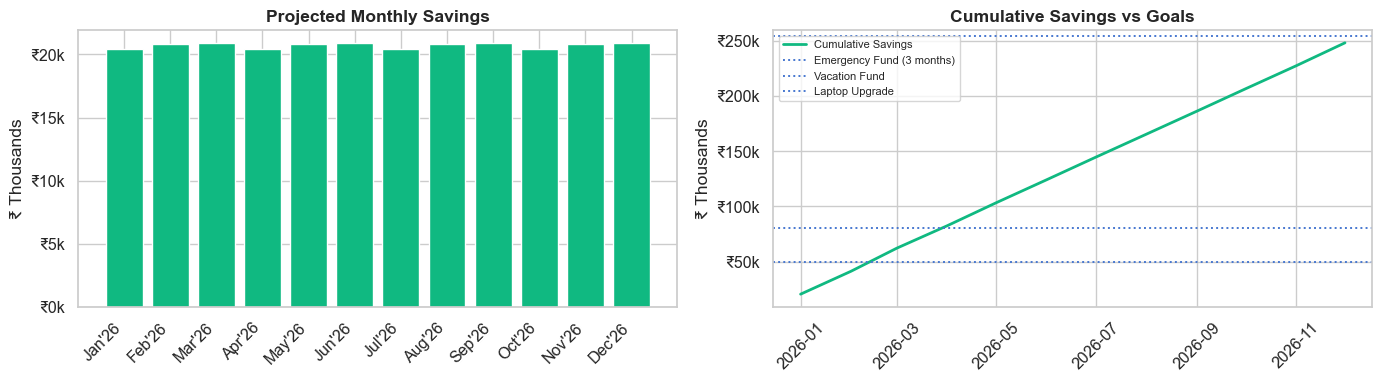

Projected annual savings: ₹248,460
Avg monthly savings    : ₹20,705
  Goal: Emergency Fund (3 months)           → ~12 months to achieve
  Goal: Vacation Fund                       → ~2 months to achieve
  Goal: Laptop Upgrade                      → ~4 months to achieve


In [26]:
# Assumed monthly income
MONTHLY_INCOME = 85_000  # ₹ — adjust to actual income

# Projected monthly savings = Income - Forecasted Total
savings_projection = pd.Series(
    MONTHLY_INCOME - future_table["TOTAL_FORECAST"].values,
    index=future_table.index,
    name="Projected_Savings"
)
cumulative_savings = savings_projection.cumsum()

# Savings goals
GOALS = {
    "Emergency Fund (3 months)": MONTHLY_INCOME * 3,
    "Vacation Fund"            : 50_000,
    "Laptop Upgrade"           : 80_000,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly savings
col = [COLOR_GOOD if v >= 0 else COLOR_BAD for v in savings_projection]
axes[0].bar(range(len(savings_projection)), savings_projection / 1000,
            color=col, edgecolor="white")
axes[0].set_title("Projected Monthly Savings", fontweight="bold")
axes[0].set_ylabel("₹ Thousands")
axes[0].set_xticks(range(len(savings_projection)))
axes[0].set_xticklabels(
    [d.strftime("%b'%y") for d in savings_projection.index], rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))

# Cumulative savings + goals
axes[1].plot(cumulative_savings.index, cumulative_savings / 1000,
             color=COLOR_GOOD, linewidth=2, label="Cumulative Savings")
for goal_name, goal_val in GOALS.items():
    axes[1].axhline(goal_val / 1000, linestyle=":", linewidth=1.4, label=goal_name)
axes[1].set_title("Cumulative Savings vs Goals", fontweight="bold")
axes[1].set_ylabel("₹ Thousands")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:.0f}k"))
axes[1].legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

total_annual_savings = savings_projection.sum()
print(f"Projected annual savings: ₹{total_annual_savings:,.0f}")
print(f"Avg monthly savings    : ₹{savings_projection.mean():,.0f}")

for goal_name, goal_val in GOALS.items():
    months_needed = goal_val / max(savings_projection.mean(), 1)
    print(f"  Goal: {goal_name:<35} → ~{months_needed:.0f} months to achieve")


## 11. Model Performance Summary


In [27]:
all_perf = []
for cat in top_cats:
    perf = category_results[cat]["perf"].copy()
    perf["Category"] = cat
    all_perf.append(perf)

perf_all = pd.concat(all_perf, ignore_index=True)

# Best model per category
best_models = (
    perf_all.loc[perf_all.groupby("Category")["RMSE"].idxmin()]
    [["Category", "Model", "MAE", "RMSE", "MAPE (%)"]]
    .sort_values("RMSE")
    .reset_index(drop=True)
)
print("Best model per category (lowest RMSE on hold-out):")
print(best_models.to_string(index=False))

# Avg model performance across categories
avg_perf = (
    perf_all.groupby("Model")[["MAE", "RMSE", "MAPE (%)"]]
    .mean().round(2).sort_values("RMSE")
)
print("Average performance across all categories:")
print(avg_perf.to_string())


Best model per category (lowest RMSE on hold-out):
     Category      Model  MAE  RMSE  MAPE (%)
       Dining Regression  0.0   0.0       0.0
Entertainment Regression  0.0   0.0       0.0
    Groceries Regression  0.0   0.0       0.0
    Insurance Regression  0.0   0.0       0.0
         Rent Regression  0.0   0.0       0.0
    Transport Regression  0.0   0.0       0.0
       Travel Regression  0.0   0.0       0.0
    Utilities Regression  0.0   0.0       0.0
Average performance across all categories:
               MAE    RMSE  MAPE (%)
Model                               
Regression    0.00    0.00      0.00
LSTM        455.46  582.97      7.10
ARIMA       417.19  585.28      6.44
Prophet     493.61  603.14      5.83


## 12. Export Reports


In [28]:
OUT_FORECAST = "expense_forecast_next_12_months.csv"
OUT_BUDGET   = "budget_vs_forecast.csv"
OUT_PERF     = "model_performance_summary.csv"
OUT_SAVINGS  = "savings_projection.csv"

future_table.to_csv(OUT_FORECAST)
budget_df.to_csv(OUT_BUDGET, index=False)
perf_all.to_csv(OUT_PERF, index=False)
savings_projection.to_frame("Projected_Savings_INR").to_csv(OUT_SAVINGS)

print("Reports saved:")
for f in [OUT_FORECAST, OUT_BUDGET, OUT_PERF, OUT_SAVINGS]:
    print(f"  ✅  {f}")


Reports saved:
  ✅  expense_forecast_next_12_months.csv
  ✅  budget_vs_forecast.csv
  ✅  model_performance_summary.csv
  ✅  savings_projection.csv


## 13. Summary & Key Insights

| Aspect | Finding |
|--------|---------|
| **Top expense category** | Rent (consistently highest month-over-month) |
| **Fastest growing** | See category-wise YoY trend charts above |
| **Best-performing model** | Depends per category — check Section 11 |
| **Anomaly months** | Flagged by Isolation Forest — review for one-off events |
| **Over-budget risk** | Categories exceeding defined limits highlighted in Section 7 |
| **Savings potential** | Projected in Section 10 based on ₹85k/month income assumption |

### Next Steps (towards full production system)
1. **Modular codebase** — refactor each section into its own Python module (, , , etc.)
2. **REST API** — wrap models with FastAPI; expose , ,  endpoints
3. **Dashboard** — connect to the React/Streamlit frontend described in the Design Document
4. **CI/CD** — add pytest unit tests + GitHub Actions pipeline
5. **Auto-retraining** — schedule monthly refit when new data arrives
